# List of Topics Covered
- 1. [Brief Basics of Vector Embeddings](#1-brief-basics-of-vector-embeddings)
    - 1.1. [What Are Embeddings?](#11-what-are-embeddings)
    - 1.2. [Measuring Similarilty](#12-measuring-similarity)
- 2. [Creating your first Embedding](#2-creating-your-first-embedding)
    - 2.1. [Hugginface Models (Open Source)](#21-hugginface-models-open-source)
    - 2.2. [OpenAI Embeddings](#22-openai-embeddings)


## 1. Brief Basics of Vector Embeddings

### 1.1. What Are Embeddings?
Think of embeddings as a way to translate words into a language that computers understand - numbers!

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Simplified 2D example (real embeddings have hundreds of dimensions)
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

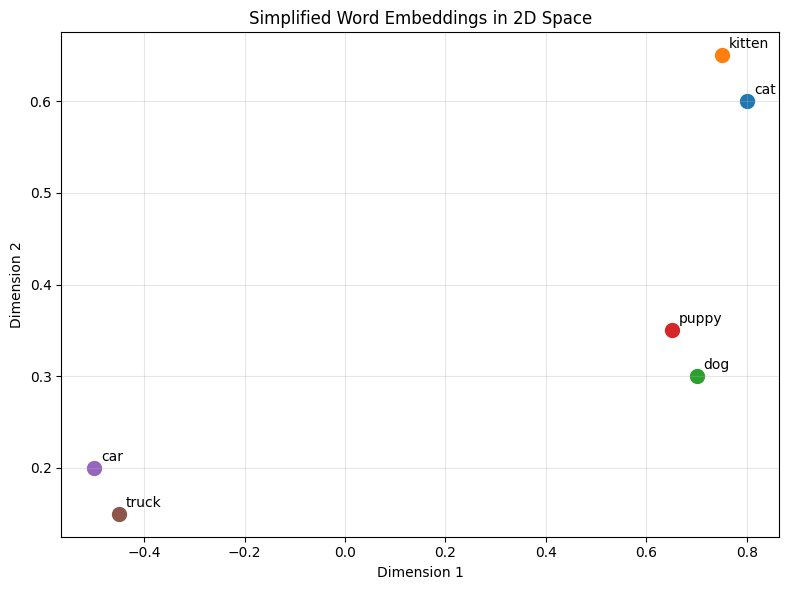

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), 
                textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.2. Measuring Similarity

In [5]:
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """

    dot_product=np.dot(vec1,vec2)
    norm_a=np.linalg.norm(vec1)
    norm_b=np.linalg.norm(vec2)
    return dot_product/(norm_a * norm_b)

In [6]:
# Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

In [7]:
print(cosine_similarity(cat_vector,kitten_vector))
print(cosine_similarity(cat_vector,car_vector))

0.9966186334192183
-0.4371858854891681


## 2. Creating your first Embedding

### 2.1. Hugginface Models (Open Source)

In [10]:
### Huggingface And OpenAI Models
from langchain_huggingface import HuggingFaceEmbeddings

## Initialize a simple Embedding model(no API Key needed!)
embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

c:\Users\mrinm\Downloads\MyTraining\AI_ML_Courses\RAG\RAG_bootcamp_Udemy_Krish\codebase\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\mrinm\Downloads\MyTraining\AI_ML_Courses\RAG\RAG_bootcamp_Udemy_Krish\codebase\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mrinm\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To su

In [11]:
embeddings

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [12]:
## create your first embeddings
text="Hello, I am learning about embeddings!"

embedding=embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embedding length : {len(embedding)}")
print(embedding)


Text: Hello, I am learning about embeddings!
Embedding length : 384
[-0.018163269385695457, -0.09955170750617981, 0.013816054910421371, -0.008125903084874153, 0.014152245596051216, 0.06406480818986893, -0.006253290921449661, -0.003017896320670843, 0.025287188589572906, -0.020198598504066467, 0.02432972751557827, 0.07435055077075958, 0.05117721110582352, 0.022038443014025688, -0.05830613896250725, 0.0152682363986969, 0.023584401234984398, 0.09455389529466629, -0.06508851051330566, 0.01329665444791317, -0.020497595891356468, -0.05690856650471687, 0.03030330315232277, -0.08365614712238312, 0.0265963077545166, -0.015231486409902573, -0.04361541569232941, 0.053983982652425766, 0.0902571976184845, -0.08893883228302002, 0.03964455425739288, -0.00883496180176735, -0.030343713238835335, 0.07425562292337418, -0.054099150002002716, 0.11108003556728363, 0.03689984977245331, -0.008959818631410599, -0.061402350664138794, -0.0031433545518666506, 0.021958187222480774, 0.042208198457956314, -0.02893787

In [13]:
sentences = [
    "The cat sat on the mat",
    "The cat sat on the mat",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]

embedding_sentence=embeddings.embed_documents(sentences)

print(embedding_sentence[0])
print(embedding_sentence[1])

[0.1304018497467041, -0.011870170012116432, -0.028116997331380844, 0.05123865231871605, -0.05597449094057083, 0.03019159846007824, 0.030161255970597267, 0.02469838410615921, -0.018370557576417923, 0.058766771107912064, -0.024953216314315796, 0.06015418842434883, 0.039831724017858505, 0.03323051333427429, -0.06131140515208244, -0.04937310144305229, -0.05486353114247322, -0.04007603973150253, 0.05642912536859512, 0.03915659338235855, -0.034737102687358856, -0.013247678056359291, 0.03196621686220169, -0.06349918246269226, -0.06017862260341644, 0.07823450863361359, -0.028303824365139008, -0.047442857176065445, 0.04035928100347519, -0.006630926392972469, -0.06674100458621979, -0.004191296175122261, -0.025311673060059547, 0.05334164574742317, 0.017428122460842133, -0.09792361408472061, 0.006061288062483072, -0.06524167209863663, 0.04557254910469055, 0.023641789332032204, 0.07658486068248749, -0.010264304466545582, -0.004076778423041105, -0.06232282146811485, 0.033705271780490875, 0.018661115

In [14]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },
    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },
    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("📊 Popular Open Source Embedding Models:\n")
for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"  📏 Embedding size: {info['size']} dimensions")
    print(f"  📝 Description: {info['description']}")
    print(f"  🎯 Use case: {info['use_case']}\n")


📊 Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Fast and efficient, good quality
  🎯 Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
  📏 Embedding size: 768 dimensions
  📝 Description: Best quality, slower than MiniLM
  🎯 Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Slightly better than L6, bit slower
  🎯 Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
  📏 Embedding size: 384 dimensions
  📝 Description: Optimized for question-answering
  🎯 Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Supports 50+ languages
  🎯 Use case: Multilingual applications



### 2.2. OpenAI Embeddings

In [1]:
from langchain_openai import OpenAIEmbeddings
import os
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
openai_key = os.getenv("OPENAI_API_KEY")
if openai_key is not None:
	os.environ["OPENAI_API_KEY"] = openai_key
else:
	raise ValueError("OPENAI_API_KEY environment variable is not set.")

In [4]:
# Initialize OpenAI Embeddings
embeddings=OpenAIEmbeddings(model="text-embedding-3-small")

In [5]:
embeddings

OpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x0000022E24092900>, async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x0000022E24093230>, model='text-embedding-3-small', dimensions=None, deployment='text-embedding-ada-002', openai_api_version=None, openai_api_base=None, openai_api_type=None, openai_proxy=None, embedding_ctx_length=8191, openai_api_key=SecretStr('**********'), openai_organization=None, allowed_special=None, disallowed_special=None, chunk_size=1000, max_retries=2, request_timeout=None, headers=None, tiktoken_enabled=True, tiktoken_model_name=None, show_progress_bar=False, model_kwargs={}, skip_empty=False, default_headers=None, default_query=None, retry_min_seconds=4, retry_max_seconds=20, http_client=None, http_async_client=None, check_embedding_ctx_length=True)

In [6]:
## Single text embeddings
single_text="Langchain and Rag are amazing frameworks and projects to work on"
single_embeddings=embeddings.embed_query(single_text)
print(len(single_embeddings))
print(single_embeddings)

1536
[-0.050007786601781845, -0.031081510707736015, -0.0034399048890918493, -0.003286944702267647, 0.03265869989991188, -0.03132624924182892, -0.014466634951531887, 0.001493061427026987, -0.01057804748415947, -0.033909574151039124, 0.018178468570113182, 0.004568411037325859, -0.03817886486649513, 0.05003497749567032, 0.005989241413772106, 0.01439865306019783, -8.14194354461506e-05, -0.06227179616689682, 0.04057184234261513, 0.06520862877368927, -0.001464169006794691, -0.006070820149034262, -0.018246451392769814, 0.03295782208442688, -0.006907002534717321, -0.008334631100296974, -0.00758002744987607, 0.06330512464046478, 0.01789294369518757, -0.019796447828412056, 8.497788803651929e-05, -0.033936768770217896, -0.006420928984880447, 0.033719226717948914, 0.014942510984838009, 0.021835917606949806, -0.00574450520798564, 0.004095933865755796, -0.008096693083643913, 0.022556530311703682, 0.009626294486224651, 0.03804289922118187, 0.004422249272465706, -0.0075188432820141315, 0.0178929436951

In [7]:
print("📝 Single Text Embedding:")
print(f"Input: {single_text}")
print(f"Output: Vector of {len(single_embeddings)} dimensions")
print(f"Sample values: {single_embeddings[:5]}")

📝 Single Text Embedding:
Input: Langchain and Rag are amazing frameworks and projects to work on
Output: Vector of 1536 dimensions
Sample values: [-0.050007786601781845, -0.031081510707736015, -0.0034399048890918493, -0.003286944702267647, 0.03265869989991188]


In [8]:
# Example 2: Multiple texts at once
multiple_texts = [
    "Python is a programming language",
    "LangChain is a framework for LLM applications",
    "Embeddings convert text to numbers",
    "Vectors can be compared for similarity"
]

In [9]:
multiple_embeddings = embeddings.embed_documents(multiple_texts)

In [10]:
print("\n📚 Multiple Text Embeddings:")
print(f"Number of texts: {len(multiple_texts)}")
print(f"Number of embeddings: {len(multiple_embeddings)}")
print(f"Each embedding size: {len(multiple_embeddings[0])}")


📚 Multiple Text Embeddings:
Number of texts: 4
Number of embeddings: 4
Each embedding size: 1536


In [11]:
multiple_embeddings[0]

[-0.011004673317074776,
 -0.020408110693097115,
 0.018817074596881866,
 -0.0028302103746682405,
 0.015716591849923134,
 -0.026639673858880997,
 0.0005226965295150876,
 0.03720579296350479,
 -0.0017197990091517568,
 0.012993469834327698,
 0.021540194749832153,
 -0.0247222688049078,
 -0.009428935125470161,
 0.0018638592446222901,
 0.003916399087756872,
 0.015502413734793663,
 -0.03296302631497383,
 0.029780952259898186,
 -0.027210814878344536,
 0.010372338816523552,
 -0.001478848629631102,
 -0.009913384914398193,
 -0.05385048687458038,
 0.01543102040886879,
 0.03685902804136276,
 -0.04291720688343048,
 0.005415645893663168,
 0.03622669354081154,
 -0.01945960894227028,
 0.0011199729051440954,
 0.01297307200729847,
 -0.032351087778806686,
 -0.03653265908360481,
 0.05123955383896828,
 -0.03118840791285038,
 -0.04507938772439957,
 0.04585450515151024,
 -0.010464129038155079,
 0.06837379932403564,
 -0.015074057504534721,
 0.004041336476802826,
 -0.039163991808891296,
 0.03133119270205498,
 -0

In [12]:
# Different OpenAI embedding models
models_comparison = {
    "text-embedding-3-small": {
        "dimensions": 1536,
        "description": "Good balance of performance and cost",
        "cost_per_1m_tokens": 0.02,
        "use_case": "General purpose, cost-effective"
    },
    "text-embedding-3-large": {
        "dimensions": 3072,
        "description": "Highest quality embeddings",
        "cost_per_1m_tokens": 0.13,
        "use_case": "When accuracy is critical"
    },
    "text-embedding-ada-002": {
        "dimensions": 1536,
        "description": "Previous generation model",
        "cost_per_1m_tokens": 0.10,
        "use_case": "Legacy applications"
    }
}

# Display comparison
print("📊 OpenAI Embedding Models Comparison:\n")
for model_name, details in models_comparison.items():
    print(f"Model: {model_name}")
    print(f"  📏 Dimensions: {details['dimensions']}")
    print(f"  💰 Cost: ${details['cost_per_1m_tokens']}/1M tokens")
    print(f"  📝 Description: {details['description']}")
    print(f"  🎯 Use case: {details['use_case']}\n")

📊 OpenAI Embedding Models Comparison:

Model: text-embedding-3-small
  📏 Dimensions: 1536
  💰 Cost: $0.02/1M tokens
  📝 Description: Good balance of performance and cost
  🎯 Use case: General purpose, cost-effective

Model: text-embedding-3-large
  📏 Dimensions: 3072
  💰 Cost: $0.13/1M tokens
  📝 Description: Highest quality embeddings
  🎯 Use case: When accuracy is critical

Model: text-embedding-ada-002
  📏 Dimensions: 1536
  💰 Cost: $0.1/1M tokens
  📝 Description: Previous generation model
  🎯 Use case: Legacy applications



#### Cosine Similarity With OpenAI Embeddings

In [13]:
# Example 1: Finding similar sentences
sentences = [
    "The cat sat on the mat",
    "A feline rested on the rug",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]

In [14]:
import numpy as np
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """

    dot_product=np.dot(vec1,vec2)
    norm_a=np.linalg.norm(vec1)
    norm_b=np.linalg.norm(vec2)
    return dot_product/(norm_a * norm_b)

In [15]:
from langchain_openai import OpenAIEmbeddings
embeddings=OpenAIEmbeddings(model="text-embedding-3-small")
embeddings

OpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x0000022E24E4E490>, async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x0000022E24E4ED50>, model='text-embedding-3-small', dimensions=None, deployment='text-embedding-ada-002', openai_api_version=None, openai_api_base=None, openai_api_type=None, openai_proxy=None, embedding_ctx_length=8191, openai_api_key=SecretStr('**********'), openai_organization=None, allowed_special=None, disallowed_special=None, chunk_size=1000, max_retries=2, request_timeout=None, headers=None, tiktoken_enabled=True, tiktoken_model_name=None, show_progress_bar=False, model_kwargs={}, skip_empty=False, default_headers=None, default_query=None, retry_min_seconds=4, retry_max_seconds=20, http_client=None, http_async_client=None, check_embedding_ctx_length=True)

In [16]:
sentence_embeddings=embeddings.embed_documents(sentences)
sentence_embeddings

[[-0.030714871361851692,
  -0.04953677952289581,
  -0.005044814199209213,
  -0.001534289331175387,
  0.03624768555164337,
  -0.0020198647398501635,
  -0.008926186710596085,
  0.027172837406396866,
  0.00706467917189002,
  -0.011892964132130146,
  0.04162537306547165,
  -0.0014001702656969428,
  0.04519326239824295,
  0.052768561989068985,
  0.03205929324030876,
  0.03249881789088249,
  -0.012397121638059616,
  0.0030766581185162067,
  -0.06608351320028305,
  0.04746843874454498,
  0.025828415527939796,
  -0.04542595148086548,
  -0.003490326227620244,
  0.014594734646379948,
  0.009113630279898643,
  0.014827422797679901,
  -0.011194898746907711,
  -0.012048088945448399,
  0.010735984891653061,
  0.012823717668652534,
  0.012248460203409195,
  -0.036066703498363495,
  -0.026526479050517082,
  -0.0453483872115612,
  -0.03456715866923332,
  0.004779807757586241,
  -0.019856078550219536,
  -0.011757228523492813,
  -0.04206489399075508,
  -0.022842247039079666,
  -0.0363769568502903,
  -0.0

In [17]:
## Calculate the simialrity betwween all pairs

for i in range(len(sentences)):
    for j in range(i+1,len(sentences)):
        similarity=cosine_similarity(sentence_embeddings[i],sentence_embeddings[j])

        print(f"'{sentences[i]}' vs '{sentences[j]}'")
        print(f"Similarity: {similarity:.3f}\n")

'The cat sat on the mat' vs 'A feline rested on the rug'
Similarity: 0.656

'The cat sat on the mat' vs 'The dog played in the yard'
Similarity: 0.324

'The cat sat on the mat' vs 'I love programming in Python'
Similarity: 0.089

'The cat sat on the mat' vs 'Python is my favorite programming language'
Similarity: 0.120

'A feline rested on the rug' vs 'The dog played in the yard'
Similarity: 0.296

'A feline rested on the rug' vs 'I love programming in Python'
Similarity: 0.055

'A feline rested on the rug' vs 'Python is my favorite programming language'
Similarity: 0.103

'The dog played in the yard' vs 'I love programming in Python'
Similarity: 0.126

'The dog played in the yard' vs 'Python is my favorite programming language'
Similarity: 0.085

'I love programming in Python' vs 'Python is my favorite programming language'
Similarity: 0.708



In [18]:
### Example- Semantic Search- Retireve the similar sentence
# Test semantic search
documents = [
    "LangChain is a framework for developing applications powered by language models",
    "Python is a high-level programming language",
    "Machine learning is a subset of artificial intelligence",
    "Embeddings convert text into numerical vectors",
    "The weather today is sunny and warm"
]
query="What is Langchain?"

In [19]:
def semantic_search(query,documents,embeddings_models,top_k=3):
    """Simple semantic search implementation"""

    ## embed query and doument

    query_embedding=embeddings_models.embed_query(query)
    doc_embeddings = embeddings_models.embed_documents(documents)

    ## Calculate the similarity score

    similarties=[]

    for i,doc_emb in enumerate(doc_embeddings):
        similarity=cosine_similarity(query_embedding,doc_emb)
        similarties.append((similarity,documents[i]))

    ## Sort by similarity
    similarties.sort(reverse=True)
    return similarties[:top_k]


In [20]:
results=semantic_search(query,documents,embeddings)
results

[(np.float64(0.6756871264409867),
  'LangChain is a framework for developing applications powered by language models'),
 (np.float64(0.13019324398567036),
  'Python is a high-level programming language'),
 (np.float64(0.10106358201980059),
  'Embeddings convert text into numerical vectors')]

In [21]:
print(f"\n🔎 Semantic Search Results for: '{query}'")
for score, doc in results:
    print(f"Score: {score:.3f} | {doc}")


🔎 Semantic Search Results for: 'What is Langchain?'
Score: 0.676 | LangChain is a framework for developing applications powered by language models
Score: 0.130 | Python is a high-level programming language
Score: 0.101 | Embeddings convert text into numerical vectors


In [22]:
query="What is Embeddings?"
results=semantic_search(query,documents,embeddings)
results

[(np.float64(0.6228397102483632),
  'Embeddings convert text into numerical vectors'),
 (np.float64(0.25210122491990816),
  'Machine learning is a subset of artificial intelligence'),
 (np.float64(0.22919241324405515),
  'LangChain is a framework for developing applications powered by language models')]